In [21]:
import shutil
import re
import os
pattern = re.compile(r'@objective\(m, (Min|Max), ([\w\[\]]+)\)')
for folder in ["qcqp"]:#os.listdir('instances'):
    if not os.path.isdir(f'instances/{folder}'):
        continue
    for filename in os.listdir(f'instances/{folder}'):
        outlines = []
        with open(f'instances/{folder}/{filename}') as infile:
            instr = infile.read()
            values = pattern.findall(instr)
            if values == []:
                continue
            values = values[0]
            pattern2 = re.compile(r',\s*-(\(.*\))\+'+f'{values[-1]}'.replace('[', '\[').replace(']', '\]'))
            found = False
            if values == []:
                continue
            for line in instr.splitlines():
                if "+{}".format(values[-1]) in line:
                    found = True
                    outlines.append(f'@objective(m, Min, {pattern2.findall(line)[0]})')
                    print(outlines[-1])
                elif 'objective' in line:
                    continue
                else:
                    outlines.append(line.strip().replace('NLcon', 'con'))
        with open(f'instances/{folder}/{filename}', 'w') as newfile:
            newfile.write('\n'.join(outlines))
        # break
    # break
        # assert found,f"{folder} {filename} {values}"

@objective(m, Min, (-1.36*x[3]*x[6]-0.3*x[3]*x[8]+1.7*x[3]*x[9]+1.77*x[4]*x[6]-0.64*x[4]*x[8]-0.99*x[4]*x[9]+1.66*x[5]*x[6]+0.69*x[5]*x[9]+0.56*x[3]-0.23*x[4]+0.72*x[5]+0.84*x[6]-0.06*x[8]-0.19*x[9]))
@objective(m, Min, (1.75*x[2]*x[20]-0.26*x[2]*x[19]-0.81*x[2]*x[21]-0.2*x[2]*x[23]+1.41*x[2]*x[25]+0.27*x[2]*x[27]+1.99*x[2]*x[28]-1.22*x[2]*x[29]+1.37*x[3]*x[18]+0.64*x[3]*x[20]+1.42*x[3]*x[21]+1.33*x[3]*x[23]-1.93*x[3]*x[24]-1.25*x[3]*x[26]+0.39*x[4]*x[16]-1.5*x[4]*x[17]-0.53*x[4]*x[19]+0.23*x[4]*x[22]-0.5*x[4]*x[23]+0.7*x[4]*x[24]-0.31*x[4]*x[27]-0.06*x[4]*x[28]+1.14*x[5]*x[17]+1.71*x[5]*x[18]+1.23*x[5]*x[19]-0.7*x[5]*x[20]-0.46*x[5]*x[21]+1.04*x[5]*x[23]-0.04*x[5]*x[27]+1.18*x[6]*x[17]+0.81*x[6]*x[19]+0.96*x[6]*x[20]+0.42*x[6]*x[24]+0.8*x[6]*x[27]-0.17*x[6]*x[28]+0.9*x[7]*x[20]+0.33*x[7]*x[23]+0.78*x[7]*x[24]+0.04*x[8]*x[16]+2*x[8]*x[18]-1.54*x[8]*x[21]-0.91*x[8]*x[23]+0.46*x[8]*x[24]-0.9*x[8]*x[25]+1.35*x[8]*x[26]-1.41*x[8]*x[27]+1.45*x[8]*x[29]+0.47*x[9]*x[18]-0.85*x[9]*x[16]-0.76*x

<>:16: SyntaxWarning: invalid escape sequence '\['
<>:16: SyntaxWarning: invalid escape sequence '\]'
<>:16: SyntaxWarning: invalid escape sequence '\['
<>:16: SyntaxWarning: invalid escape sequence '\]'
/tmp/ipykernel_444857/3414155809.py:16: SyntaxWarning: invalid escape sequence '\['
  pattern2 = re.compile(r',\s*-(\(.*\))\+'+f'{values[-1]}'.replace('[', '\[').replace(']', '\]'))
/tmp/ipykernel_444857/3414155809.py:16: SyntaxWarning: invalid escape sequence '\]'
  pattern2 = re.compile(r',\s*-(\(.*\))\+'+f'{values[-1]}'.replace('[', '\[').replace(']', '\]'))


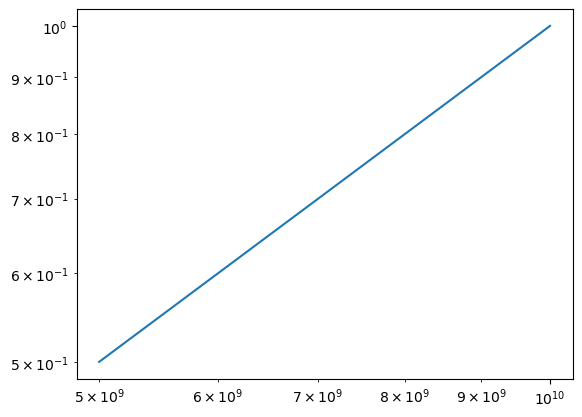

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
# df = pd.read_csv('test.csv')
# ax=sns.boxplot(df,
#                    x='bits',
#                    hue='N',
#                    y='dist',
#                    palette=sns.color_palette())
# ax.set_ylim(1e-7, 1)
# ax.set_yscale('log')
x = np.linspace(5e9, 10e9, 50)
P = 10e3 # per cm sq
Ic = 160e-6
hbar = 6.626e-34 / (2 * np.pi)
e = 1.6e-19
phi_0 = np.pi * hbar / e
def get_flux(I_dc):
    return I_dc / P
get_flux = np.vectorize(get_flux)
Lsquid = hbar / (2 * e * Ic)  / np.abs(np.cos(np.pi * get_flux(10e-6) / phi_0))
w0 = 7.5e9 * x * (1 + (Lsquid + 7.5e-12 / 2) / 101e-12)
w0 /= w0.max()
ax=sns.lineplot(x=x, y=w0)
ax.set_xscale('log')
ax.set_yscale('log')
